# GBM analysis

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

## Read data

In [89]:
PATH_MODULES = "../datasets/module-predictions/"

In [90]:
samples_modules = dict()

In [91]:
for file_ in os.listdir(PATH_MODULES):
    if 'modules' in file_:
        data = pd.read_csv(PATH_MODULES + file_, sep = '\t')
        # data = data[data['Coverage'] >= 0.5]
        # samples_modules[file_.split('.')[0]] = data
        samples_modules[file_.split('.')[0]] = pd.read_csv(PATH_MODULES + file_, sep = '\t')

## Presence graph

In [92]:
gbm_metadata = pd.read_excel("../datasets/41564_2018_337_MOESM4_ESM.xlsx", sheet_name="Supplementary Table 10", skiprows = 1)

C:\Users\rafap\anaconda3\envs\clustering-env\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [93]:
gbm_count = dict()

In [94]:
for gbm in list(gbm_metadata['Module.number']):
    gbm_count[gbm] = 0

In [95]:
for sample in samples_modules:
    for gbm in set(samples_modules[sample]['Module']):
        gbm_count[gbm] += 1

In [96]:
df = pd.DataFrame(list(gbm_count.items()), columns=['GBM', 'Count'])

In [97]:
df['Count'] = df['Count'] / len(samples_modules)

In [98]:
gbm_metadata.head()

,Module.number,Description,Label in Figure 3,Function,Structure,Pathway,Depression association reported,Depression association reference,Name_DB,Code,BBB.Prediction,BBB.Probability,Int.Prediction,Int.Probability,Unnamed: 14
0,MGB049,Tryptophan degradation,Trp deg,Amino acid,Amino acid,Tryptophan-derived,1,"PMID:2521647,11888576,11022402,26805875",L-Tryptophan,DB00150,+,0.9510,+,0.9840,* Predictions for each compound to cross the b...
1,MGB050,Glutamate degradation I,Glu deg I,Amino acid/ Neurotransmitter,Amino acid,Glutamate-derived,1,"PMID: 22731961,11986998,21827775",L-Glutamic Acid,DB00142,NaN,NaN,NaN,NaN,NaN
2,MGB051,Glutamate degradation II,Glu deg II,Amino acid/ Neurotransmitter,Amino acid,Glutamate-derived,1,"PMID: 22731961,11986998,21827775",L-Glutamic Acid,DB00142,NaN,NaN,NaN,NaN,NaN
3,MGB052,Butyrate synthesis I,Butyrate synt I,SCFA,SCFA,Butyrate,0,NaN,Isobutyric Acid,DB02531,+,0.9624,+,0.9848,NaN
4,MGB053,Butyrate synthesis II,Butyrate synt II,SCFA,SCFA,Butyrate,0,NaN,Isobutyric Acid,DB02531,+,0.9624,+,0.9848,NaN


In [99]:
labels = []
for gbm in list(df['GBM']):
    labels.append(gbm_metadata[gbm_metadata['Module.number'] == gbm]['Label in Figure 3'].iloc[0])

In [100]:
df['Labels'] = labels

In [101]:
df

,GBM,Count,Labels
0,MGB049,0.000000,Trp deg
1,MGB050,0.000000,Glu deg I
2,MGB051,0.063725,Glu deg II
3,MGB052,0.549020,Butyrate synt I
4,MGB053,0.107843,Butyrate synt II
5,MGB054,0.000000,Propionate synt II
6,MGB055,0.392157,Propionate synt III
7,MGB056,0.186275,Propionate deg I
8,MGB001,0.000000,Serotonin synt I
9,MGB002,0.000000,Serotonin synt II


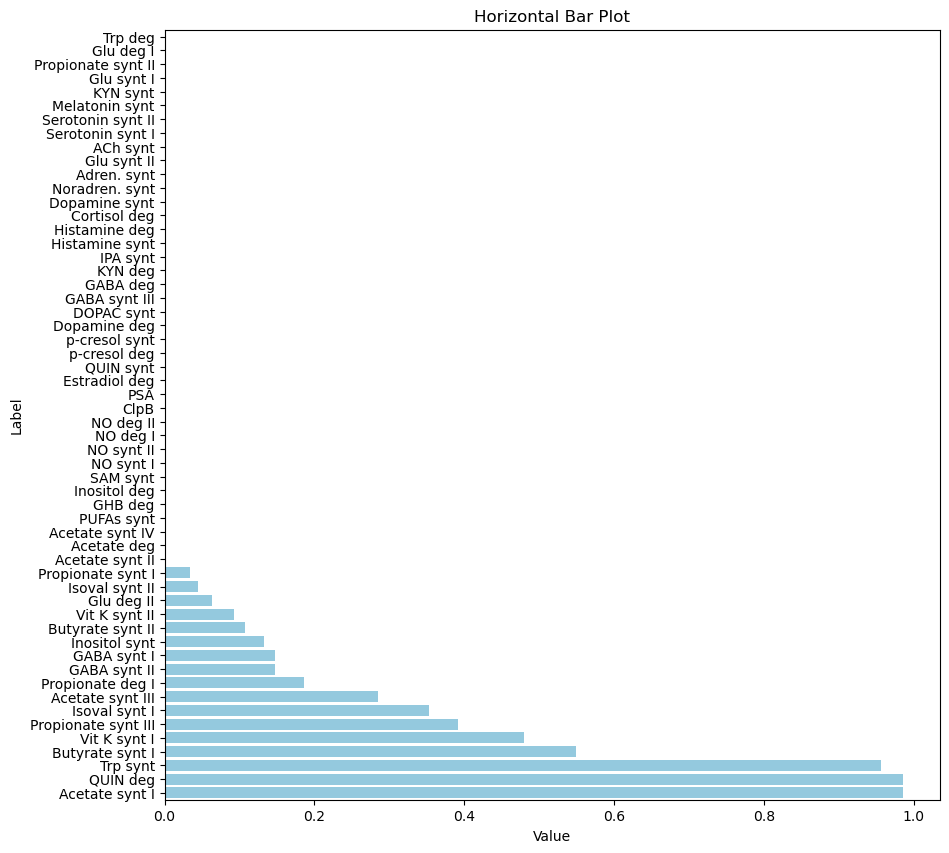

In [102]:
df = df.sort_values(by='Count', ascending=True)
plt.figure(figsize=(10, 10))  # Optional: Adjust the figure size
sns.barplot(data=df, y='Labels', x='Count', orient='h', color="skyblue")

# Add labels and title
plt.xlabel("Value")
plt.ylabel("Label")
plt.title("Horizontal Bar Plot")

# Show the plot
plt.show()